In [23]:
from mne.decoding import CSP
from sklearn.model_selection import StratifiedKFold
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LDA
from sklearn import metrics
import tqdm

import numpy as np
import sys, os

import dataset_BCICIV2a
from config_BCICIV2a import Config

import pywt
import cv2 

import matplotlib.pyplot as plt

config = Config()

# Choose from: 'Left', 'Right', 'Foot' and 'Tongue'
config.used_classes = ['Right', 'Tongue']


config.t_start = -0.1
config.t_end = 2.5

config.n_csp_components = 3

subject_id = 1

X, y = dataset_BCICIV2a.subject_dataset(config, subject_id)

Extracting EDF parameters from /home/antaeus/Neurobus/BCICIV_2a_gdf/A01T.gdf...
GDF file detected
Setting channel info structure...
Could not determine channel type of the following channels, they will be set as EEG:
EEG-Fz, EEG, EEG, EEG, EEG, EEG, EEG, EEG-C3, EEG, EEG-Cz, EEG, EEG-C4, EEG, EEG, EEG, EEG, EEG, EEG, EEG, EEG-Pz, EEG, EEG
Creating raw.info structure...
NOTE: pick_channels() is a legacy function. New code should use inst.pick(...).
Used Annotations descriptions: ['1023', '1072', '276', '277', '32766', '768', '769', '770', '771', '772']
Not setting metadata
144 matching events found
Setting baseline interval to [-0.1, 0.0] s
Applying baseline correction (mode: mean)
0 projection items activated
Loading data for 72 events and 651 original time points ...
0 bad epochs dropped
Loading data for 72 events and 651 original time points ...
0 bad epochs dropped


/usr/lib/python3.10/contextlib.py:142: RuntimeWarning: Channel names are not unique, found duplicates for: {'EEG'}. Applying running numbers for duplicates.
  next(self.gen)


In [51]:
X.shape

(144, 17, 651)

In [54]:
x = X[:16, :3]
print(x.shape)
time = np.linspace(0,1,651)#np.linspace(0, 1, len(x))

(16, 3, 651)


(225, 16, 3, 651)
(224, 16, 3, 650)


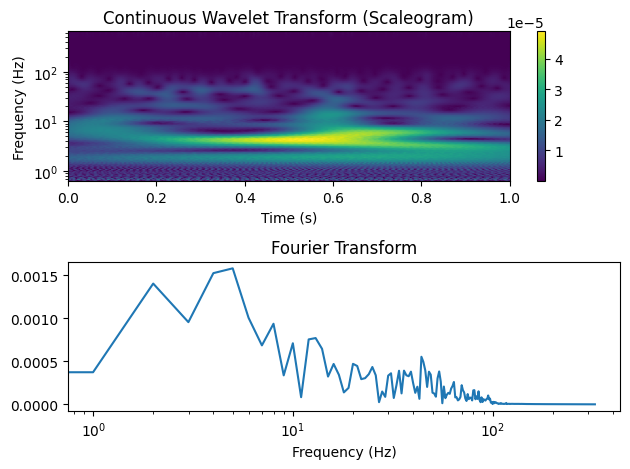

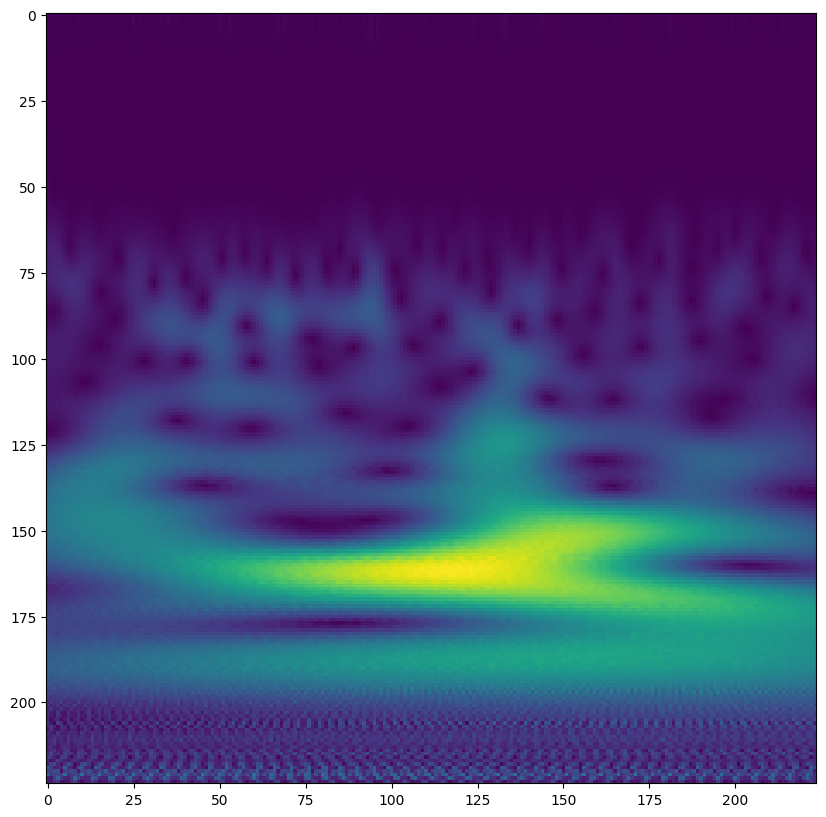

In [61]:
# perform CWT
wavelet = "cmor1.5-1.0"
# logarithmic scale for scales, as suggested by Torrence & Compo:
widths = np.geomspace(1, 1024, num=225)
sampling_period = np.diff(time).mean()
cwtmatr, freqs = pywt.cwt(x, widths, wavelet, sampling_period=sampling_period)
# absolute take absolute value of complex result
print(cwtmatr.shape)
cwtmatr = np.abs(cwtmatr[:-1,:, :, :-1])

print(cwtmatr.shape)

# plot result using matplotlib's pcolormesh (image with annoted axes)
fig, axs = plt.subplots(2, 1)
pcm = axs[0].pcolormesh(time, freqs, cwtmatr[:, 0, 0])
axs[0].set_yscale("log")
axs[0].set_xlabel("Time (s)")
axs[0].set_ylabel("Frequency (Hz)")
axs[0].set_title("Continuous Wavelet Transform (Scaleogram)")
fig.colorbar(pcm, ax=axs[0])

# plot fourier transform for comparison
from numpy.fft import rfft, rfftfreq

yf = rfft(x[0,0])
xf = rfftfreq(len(x[0,0]), sampling_period)
plt.semilogx(xf, np.abs(yf))
axs[1].set_xlabel("Frequency (Hz)")
axs[1].set_title("Fourier Transform")
plt.tight_layout()


plt.figure(figsize=(10,10))

x_resized = []
for n in range(x.shape[0]):
    x_channels = []
    for ch in range(x.shape[1]):
        x_channels.append(cv2.resize(cwtmatr[:, n, ch], (224,224), interpolation=cv2.INTER_CUBIC))
        
    x_resized.append(np.array(x_channels))

plt.imshow(x_resized[0][0])

In [38]:
widths = np.geomspace(1, 512, num=225)